In [1]:
# Import initial libraries
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load your modeling dataset from S3
# Replace the path below with your actual S3 path from Day 26
s3 = boto3.client('s3')
bucket_name = 'cmse492-maciej21-nyc311-533267005618-us-east-1-an' # replace with your bucket name (make sure you have the account regional suffix)
file_name = 'modeling/modeling_data.csv' # make sure to include the path if it's in a folder, e.g. 'modeling/modeling_data.csv'

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (173851, 8)


,agency,borough,problem,incident_zip,day_of_week,hour_of_day,same_day_complaint_volume,days_to_close
0,DCWP,QUEENS,Consumer Complaint,11432.0,5,12,19,19
1,DCWP,BRONX,Consumer Complaint,10470.0,5,16,19,33
2,DCWP,BRONX,Consumer Complaint,10467.0,5,14,19,3
3,DCWP,QUEENS,Consumer Complaint,11354.0,5,9,19,4
4,DCWP,BROOKLYN,Consumer Complaint,11214.0,5,16,19,33


In [3]:
# Quick data check — confirm the shape, column names, and target variable
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']

Missing values:
agency                          0
borough                         0
problem                         0
incident_zip                 1765
day_of_week                     0
hour_of_day                     0
same_day_complaint_volume       0
days_to_close                   0
dtype: int64

Data types:
agency                        object
borough                       object
problem                       object
incident_zip                 float64
day_of_week                    int64
hour_of_day                    int64
same_day_complaint_volume      int64
days_to_close                  int64
dtype: object


In [5]:
df = df.dropna()

# Define feature columns and target column
# Replace these with your actual column names
feature_cols = ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']  # <-- update this
target_col   = 'days_to_close'          # <-- update this


# If your target needs to be binarized or modified in some way, do it here
# Example: df['high_volume'] = (df['volume_quartile'] == 1).astype(int)

X = df[feature_cols]
y = df[target_col].astype(float)

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Features: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']
Target: days_to_close

Target distribution:
days_to_close
0.0     106992
1.0      17454
2.0      12225
3.0       8085
4.0       5758
5.0       4518
6.0       3094
7.0       1909
8.0       1396
9.0       1229
10.0       819
11.0       722
12.0       677
13.0       606
14.0       551
15.0       490
16.0       444
17.0       430
19.0       391
18.0       375
20.0       321
21.0       281
22.0       271
23.0       264
26.0       230
30.0       225
25.0       224
24.0       214
27.0       186
29.0       170
28.0       167
32.0       161
31.0       153
33.0       137
35.0       106
36.0        98
34.0        97
40.0        85
38.0        78
37.0        76
41.0        70
39.0        69
42.0        53
45.0        38
43.0        37
44.0        34
46.0        29
48.0        19
47.0        16
49.0        12
Name: count, dtype: int64

Class balance: {0.0: 0.622, 1.0: 0.101, 2.0: 0.

In [6]:
# Import train_test_split for splitting the data
from sklearn.model_selection import train_test_split

# Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  137668 rows
Test set:      34418 rows

Class balance in training set:
days_to_close
0.0     0.621
1.0     0.102
2.0     0.072
3.0     0.047
4.0     0.034
5.0     0.026
6.0     0.018
7.0     0.011
8.0     0.008
9.0     0.007
10.0    0.005
11.0    0.004
12.0    0.004
13.0    0.004
14.0    0.003
15.0    0.003
16.0    0.003
17.0    0.003
19.0    0.002
18.0    0.002
20.0    0.002
21.0    0.002
23.0    0.002
22.0    0.002
26.0    0.001
25.0    0.001
24.0    0.001
30.0    0.001
29.0    0.001
27.0    0.001
28.0    0.001
32.0    0.001
31.0    0.001
33.0    0.001
35.0    0.001
36.0    0.001
34.0    0.001
40.0    0.001
37.0    0.000
41.0    0.000
38.0    0.000
39.0    0.000
42.0    0.000
45.0    0.000
43.0    0.000
46.0    0.000
44.0    0.000
48.0    0.000
47.0    0.000
49.0    0.000
Name: proportion, dtype: float64

Class balance in test set:
days_to_close
0.0     0.626
1.0     0.100
2.0     0.066
3.0     0.048
4.0     0.033
5.0     0.028
6.0     0.019
7.0     0.011
8.0     0.008


In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical vs. numeric columns automatically
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns     ({len(num_cols)}): {num_cols}")

# Build the transformer:
#   - OneHotEncoder for categorical columns
#     drop='first'         avoids multicollinearity (k-1 dummies per feature)
#     sparse_output=False  returns a regular numpy array (easier to inspect)
#     handle_unknown='ignore'  silently zeros out categories not seen in training
#   - StandardScaler for numeric columns (optional but often helpful for models like Logistic Regression)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),  # scale numeric columns
    ]
)

# Fit ONLY on training data, then apply to both splits
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

# Recover feature names for later coefficient inspection
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")

Categorical columns (3): ['agency', 'borough', 'problem']
Numeric columns     (4): ['incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']

Encoded feature matrix shape: (137668, 161)
Total features after encoding: 161

First few encoded feature names: ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD']


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_enc, y_train)

print("Model trained successfully.")

Model trained successfully.


In [15]:
# Inspect the model coefficients
# After encoding, use encoded_feature_names instead of feature_cols
feature_importance_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature importances (top 10):")
print(feature_importance_df.head(10).to_string(index=False))

Feature importances (top 10):
                           feature  importance
                        agency_HPD    0.281048
                       agency_NYPD    0.247511
         same_day_complaint_volume    0.206603
                      incident_zip    0.053024
                       hour_of_day    0.028249
      problem_UNSANITARY CONDITION    0.024431
                  problem_PLUMBING    0.024248
                       day_of_week    0.022016
problem_For Hire Vehicle Complaint    0.015385
        problem_Consumer Complaint    0.014619


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on the test set
y_pred = model.predict(X_test_enc)

# Compute regression metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")

MAE:  1.721
RMSE: 3.975
R^2:  0.413


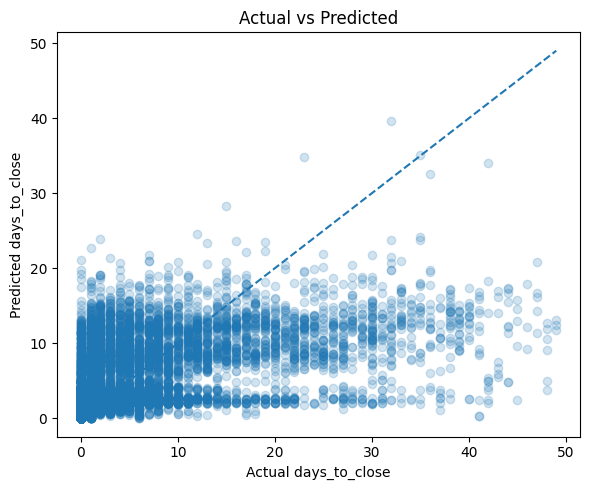

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.xlabel("Actual days_to_close")
plt.ylabel("Predicted days_to_close")
plt.title("Actual vs Predicted")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.tight_layout()
plt.show()